# LACSS GRPC call Demo

This is a small notebook demonstrating LACSS model inference by GRPC call to an inference server




## Setting up the environment

In [1]:
!pip install git+https://github.com/jiyuuchc/lacss
!pip install --upgrade protobuf

  Cloning https://github.com/jiyuuchc/lacss to /tmp/pip-req-build-h9l_hdrd
  Running command git clone --filter=blob:none --quiet https://github.com/jiyuuchc/lacss /tmp/pip-req-build-h9l_hdrd
  Resolved https://github.com/jiyuuchc/lacss to commit 4bc7d8a9999f8bf5ca249ed213cb97f44cc413d5
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.3 MB/s eta 0:00:00
  Created wheel for lacss: filename=lacss-0.0.0-py3-none-any.whl size=99258 sha256=532cfee7310f063b89b9fba412b6fc1b0570d17b901ff4da4d6b9fb721dc7674
  Stored in directory: /tmp/pip-ephem-wheel-cache-6jm22x86/wheels/3f/99/06/1

In [2]:
import cv2
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import grpc

import lacss.deploy.proto as proto
from lacss.utils import show_images

SERVER = "lacss.biopb.org"

# construct gRPC request based on given image
def construct_request(image: np.ndarray) -> proto.DetectionRequest:
    # construct request
    pixels = proto.Pixels(
        bindata = proto.BinData(data=image.tobytes()),
        size_x = image.shape[1],
        size_y = image.shape[0],
        size_c = image.shape[2],
        dimension_order = "CXYZT",
        dtype = "u1", # uint8
    )

    settings = proto.DetectionSettings(
        scaling_hint = 1.0,
    )

    request = proto.DetectionRequest(
        image_data = proto.ImageData(pixels=pixels),
        detection_settings = settings,
    )

    return request

# convert gRPC reply to a label image
def response_to_label(response: proto.DetectionResponse, image: np.ndarray) -> np.ndarray:
    label = np.zeros(image.shape[:2], dtype="uint8")

    for k, det in enumerate(response.detections):

        polygon = [[p.x, p.y] for p in det.roi.polygon.points]
        polygon = np.round(np.array(polygon)).astype(int)

        cv2.fillPoly(label, [polygon], k + 1)

    return label

## Download some data for testing

--2025-01-30 16:20:07--  https://data.mendeley.com/public-files/datasets/894mmsd9nj/files/568e524f-9a95-45a6-9f80-3619969c2a37/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/305fe4d3-50bf-4e9b-89c7-fca353116d70 [following]
--2025-01-30 16:20:07--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/305fe4d3-50bf-4e9b-89c7-fca353116d70
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.72.17, 52.92.34.226, 52.218.89.160, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.72.17|:443... c

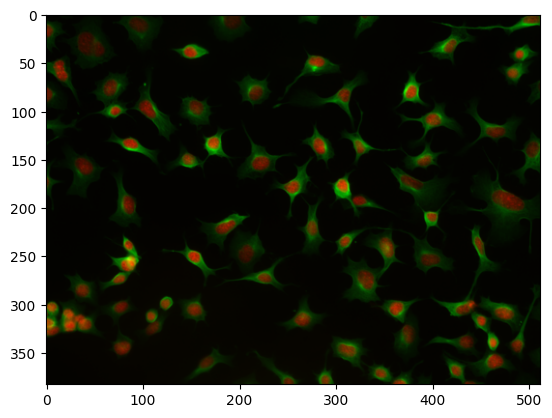

In [3]:
!wget -c https://data.mendeley.com/public-files/datasets/894mmsd9nj/files/568e524f-9a95-45a6-9f80-3619969c2a37/file_downloaded -O images.zip

import zipfile

data_path = 'image_data'
with zipfile.ZipFile('images.zip', "r") as f:
    f.extractall(data_path)

image = imageio.imread("image_data/test/000_img.png")

plt.imshow(image)

## Call GRPC server

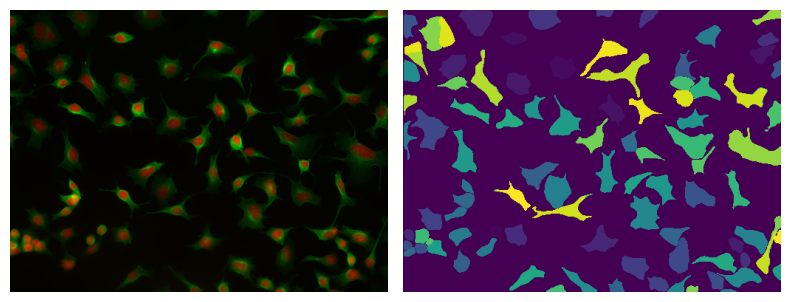

In [6]:
request = construct_request(image)

# call server
with grpc.secure_channel(
      target=SERVER,
      credentials=grpc.ssl_channel_credentials(),
    ) as channel:
    stub = proto.LacssStub(channel)
    response = stub.RunDetection(request)

# generate label
label = response_to_label(response, image)

show_images([image, label])